In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
from sklearn.datasets import make_blobs

In [13]:
x, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

In [14]:
df = pd.DataFrame(
    x,
    columns=["feature_1", "feature_2"]
)

df.head()

,feature_1,feature_2
0,-7.430860,-7.899923
1,-7.912123,-7.341576
2,-1.522144,7.549274
3,4.378661,3.291702
4,-9.325377,-8.089813


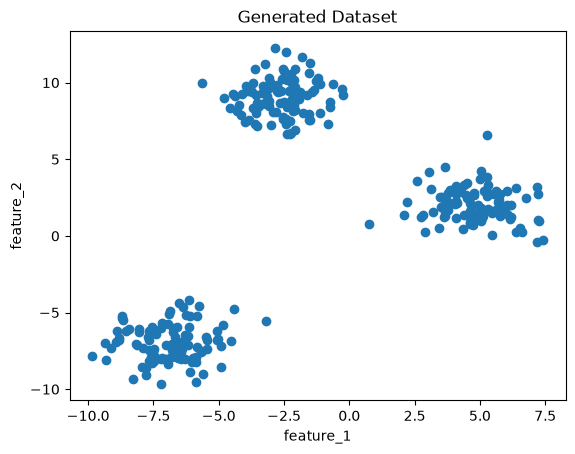

In [15]:
plt.scatter(
    df["feature_1"],
    df["feature_2"]
)

plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title("Generated Dataset")

plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [17]:
from scipy.cluster.hierarchy import linkage

In [18]:
linkage_matrix = linkage(x_scaled, method="ward")

In [19]:
linkage_matrix

array([[4.80000000e+01, 2.84000000e+02, 6.50424048e-04, 2.00000000e+00],
       [3.10000000e+01, 6.90000000e+01, 2.62172371e-03, 2.00000000e+00],
       [2.00000000e+00, 1.69000000e+02, 2.83263086e-03, 2.00000000e+00],
       ...,
       [5.84000000e+02, 5.91000000e+02, 2.60209787e+00, 1.00000000e+02],
       [5.94000000e+02, 5.96000000e+02, 1.83169287e+01, 2.00000000e+02],
       [5.95000000e+02, 5.97000000e+02, 2.85107060e+01, 3.00000000e+02]],
      shape=(299, 4))

In [20]:
from scipy.cluster.hierarchy import dendrogram

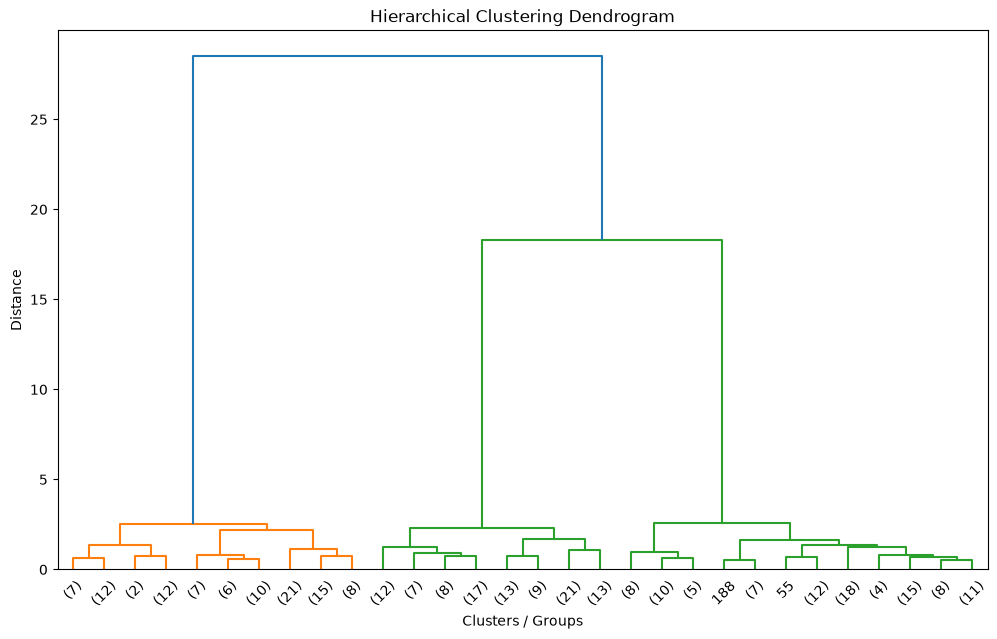

In [22]:
plt.figure(figsize=(12, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30
)

plt.xlabel("Clusters / Groups")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [23]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

In [24]:
cluster_labels = model.fit_predict(x_scaled)

In [25]:
cluster_labels

array([1, 1, 2, 0, 1, 0, 2, 0, 2, 2, 2, 0, 2, 2, 1, 2, 1, 0, 2, 2, 2, 2,
       0, 1, 2, 1, 1, 0, 0, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 0, 2, 1, 0,
       2, 2, 1, 0, 1, 0, 0, 1, 1, 2, 1, 0, 1, 2, 0, 2, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 2, 0, 1, 1, 2, 2, 1, 1, 0, 2, 0, 2, 2, 1, 2, 0, 1, 1, 2,
       0, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 0, 1,
       0, 2, 2, 2, 2, 0, 1, 0, 1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 1, 1, 2, 2,
       2, 2, 2, 0, 0, 1, 2, 1, 2, 2, 1, 2, 0, 0, 0, 2, 0, 2, 2, 1, 0, 1,
       2, 0, 0, 1, 1, 2, 2, 1, 1, 1, 2, 1, 0, 2, 2, 2, 2, 2, 0, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 0, 1, 0, 2, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       2, 1, 2, 2, 0, 0, 2, 0, 1, 1, 0, 2, 2, 1, 0, 0, 1, 1, 1, 1, 2, 1,
       1, 0, 1, 1, 2, 0, 1, 1, 0, 2, 2, 1, 2, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 2, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 1, 0, 0, 2, 2, 0, 0, 0, 1, 1, 1, 2, 2, 2, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 2, 0, 0, 2, 1, 2, 0, 2, 1, 1])

In [26]:
df["cluster"] = cluster_labels

df.head()

,feature_1,feature_2,cluster
0,-7.430860,-7.899923,1
1,-7.912123,-7.341576,1
2,-1.522144,7.549274,2
3,4.378661,3.291702,0
4,-9.325377,-8.089813,1


In [27]:
df.head()

,feature_1,feature_2,cluster
0,-7.430860,-7.899923,1
1,-7.912123,-7.341576,1
2,-1.522144,7.549274,2
3,4.378661,3.291702,0
4,-9.325377,-8.089813,1


In [28]:
df["cluster"].value_counts().sort_index()

cluster
0    100
1    100
2    100
Name: count, dtype: int64

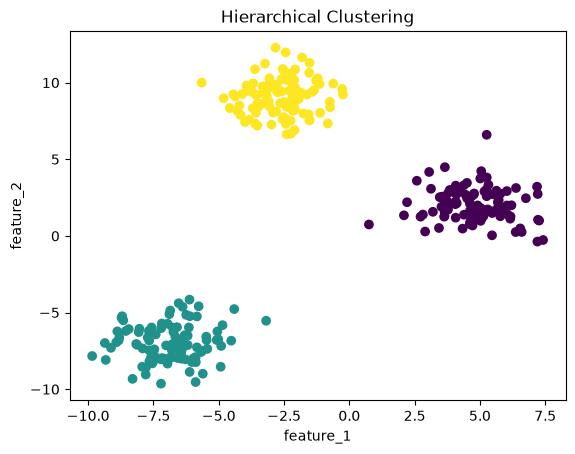

In [29]:
plt.scatter(
    df["feature_1"],
    df["feature_2"],
    c=df["cluster"]
)

plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title("Hierarchical Clustering")

plt.show()

In [ ]:
# evaluation

In [30]:
from sklearn.metrics import silhouette_score

In [31]:
score = silhouette_score(
    x_scaled,
    cluster_labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.8182412709664815


In [32]:
# comparison between different linkages

In [33]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

methods = ["single", "complete", "average", "ward"]

for method in methods:
    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )
    
    labels = model.fit_predict(x_scaled)
    
    score = silhouette_score(x_scaled, labels)
    
    print(f"{method:10} | Silhouette Score = {score:.4f}")

single     | Silhouette Score = 0.8182
complete   | Silhouette Score = 0.8182
average    | Silhouette Score = 0.8182
ward       | Silhouette Score = 0.8182


In [34]:
for method in methods:
    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )
    
    labels = model.fit_predict(x_scaled)
    
    print(f"\n{method}")
    print(np.bincount(labels))


single
[100 100 100]

complete
[100 100 100]

average
[100 100 100]

ward
[100 100 100]


# Hierarchical Clustering — Complete Notes

## 1. What is Hierarchical Clustering?

**Hierarchical Clustering** is an **unsupervised learning** technique that groups similar data points into clusters by creating a hierarchy of clusters.

It does not simply produce clusters directly. Instead, it builds a **tree-like structure** showing how individual points or clusters are progressively merged.

The most commonly used approach is:

> **Agglomerative Hierarchical Clustering**

---

# 2. Types of Hierarchical Clustering

There are two main approaches:

```text
                 Hierarchical Clustering
                         │
              ┌──────────┴──────────┐
              ↓                     ↓
        Agglomerative            Divisive
        Bottom-Up                Top-Down
              │                     │
          Merge clusters        Split clusters
```

### Agglomerative

Starts with every observation as its own cluster and repeatedly **merges** the closest clusters.

```text
A   B   C   D
│   │   │   │
└─┬─┘   └─┬─┘
  ↓       ↓
 AB      CD
   \     /
    \   /
     ABCD
```

### Divisive

Starts with one large cluster and repeatedly **splits** it.

```text
       ABCD
        │
      Split
     /     \
   AB       CD
  / \       / \
 A   B     C   D
```

In practice, **Agglomerative Clustering** is the approach we focus on.

---

# 3. Agglomerative Hierarchical Clustering

Agglomerative clustering follows a **bottom-up** approach.

Initially:

```text
Every observation = separate cluster
```

Example:

```text
A    B    C    D    E
●    ●    ●    ●    ●
│    │    │    │    │
└────┴────┴────┴────┘
     5 individual clusters
```

Then the algorithm repeatedly finds the closest clusters and merges them.

```text
A    B    C    D    E
│    │    │    │    │
└─┬──┘    └─┬──┘
  ↓         ↓
 AB        CD       E

       ↓

 AB        CD+E

       ↓

      ABCDE
```

Eventually:

```text
5 clusters
   ↓
4 clusters
   ↓
3 clusters
   ↓
2 clusters
   ↓
1 cluster
```

---

# 4. Basic Hierarchical Clustering Workflow

```text
                Raw Data
                   │
                   ↓
            Feature Selection
                   │
                   ↓
             Feature Scaling
                   │
                   ↓
          Calculate Distances
                   │
                   ↓
            Linkage Strategy
                   │
                   ↓
          Hierarchical Merging
                   │
                   ↓
             Linkage Matrix
                   │
                   ↓
              Dendrogram
                   │
                   ↓
        Choose Number of Clusters
                   │
                   ↓
      AgglomerativeClustering
                   │
                   ↓
             Cluster Labels
                   │
                   ↓
          Evaluate Clustering
```

---

# 5. Why Feature Scaling is Important

Hierarchical clustering is based on **distance**.

If features have very different scales, a feature with larger numerical values can dominate the distance calculation.

Example:

```text
Feature 1: Age
20 – 60

Feature 2: Salary
20,000 – 200,000
```

Salary has much larger numerical values.

Therefore, distance calculations can become dominated by salary.

So we commonly standardize the features:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)
```

Then clustering is performed using:

```text
x_scaled
```

instead of unscaled `x`.

---

# 6. Distance Between Clusters

At the beginning, each point is its own cluster.

The algorithm needs to answer:

> **Which two clusters should I merge?**

For example:

```text
Cluster A              Cluster B

● ●                    ● ●
 ● ●                  ● ●
```

We need some rule to determine the distance between these two clusters.

That rule is called **linkage**.

---

# 7. Linkage

**Linkage** determines how the distance between two clusters is measured.

The important linkage methods are:

```text
                    Linkage
                       │
       ┌───────────────┼───────────────┐
       ↓               ↓               ↓
    Single          Complete         Average
       │               │               │
    Closest          Farthest        Average
     pair              pair          distance
                       │
                       │
                      Ward
                       ↓
               Variance increase
```

---

# 8. Single Linkage

Single linkage uses the **closest pair of points** between two clusters.

```text
Cluster A                 Cluster B

● ●                         ● ●
 ● ●                    ●  ●
                       ↑
                  closest pair
```

Conceptually:

```text
Single Linkage
      ↓
Minimum distance
      ↓
Closest points
```

### Problem: Chaining Effect

Single linkage can create a **chain**.

```text
● ●
    ●
      ●
        ●
          ● ●
```

Even though the two ends are far apart, nearby points can gradually connect them.

This is called the:

> **Chaining effect**

---

# 9. Complete Linkage

Complete linkage uses the **farthest pair of points** between two clusters.

```text
Cluster A                  Cluster B

● ●                         ● ●
 ● ●                        ● ●
 ↑                            ↑
 └──────── farthest ─────────┘
```

Conceptually:

```text
Complete Linkage
       ↓
Maximum distance
       ↓
Farthest points
```

It tends to produce more **compact clusters**.

---

# 10. Average Linkage

Average linkage considers the **average distance between points** in the two clusters.

```text
Cluster A                  Cluster B

● ●                        ● ●
 ● ●                      ● ●
  │╲                      ╱│
  │ ╲                    ╱ │
  └─── distances ────────┘
             ↓
        Average them
```

Conceptually:

```text
Average Linkage
       ↓
Average distance
       ↓
Between the two clusters
```

It provides a middle ground between single and complete linkage.

---

# 11. Ward Linkage ⭐

Ward linkage works differently.

Instead of simply looking at the distance between clusters, it asks:

> **If I merge these two clusters, how much will the within-cluster variance increase?**

It chooses the merge that produces the **smallest increase in variance**.

```text
Cluster A          Cluster B

 ● ●                 ● ●
● ● ●               ● ●
 ● ●                 ● ●

       ↓ MERGE

    ● ● ● ● ●
   ● ● ● ● ● ●
    ● ● ● ●

       ↓

Check increase
in variance

       ↓

Choose merge
with smallest increase
```

Therefore:

```text
Ward
 ↓
Minimize increase in
within-cluster variance
 ↓
Compact clusters
```

Ward works particularly well for **compact, roughly spherical/blob-shaped clusters**.

---

# 12. Easy Way to Remember Linkage

Memorize this:

```text
Single   → Closest
Complete → Farthest
Average  → Average
Ward     → Variance
```

Or:

```text
S → Smallest distance
C → Complete/Farthest distance
A → Average distance
W → Within-cluster variance
```

---

# 13. Linkage Matrix

We can create the hierarchy using:

```python
from scipy.cluster.hierarchy import linkage

linkage_matrix = linkage(
    x_scaled,
    method="ward"
)
```

`linkage()` calculates and stores the sequence of merges.

Each row contains information about one merge.

Conceptually:

```text
┌────────────┬────────────┬──────────┬──────────────┐
│ Cluster 1  │ Cluster 2  │ Distance │ Cluster Size │
├────────────┼────────────┼──────────┼──────────────┤
│     A      │     B      │   0.5    │      2       │
│     C      │     D      │   0.8    │      2       │
│    AB      │    CD      │   2.1    │      4       │
└────────────┴────────────┴──────────┴──────────────┘
```

For `n` observations:

```text
Number of merges = n - 1
```

For our dataset:

```text
300 observations
       ↓
299 merges
```

Therefore:

```python
linkage_matrix.shape
```

returns:

```text
(299, 4)
```

The `4` represents:

```text
1. First cluster
2. Second cluster
3. Distance
4. Number of observations in new cluster
```

---

# 14. Dendrogram 🌳

A **dendrogram** is a tree-like visualization of the hierarchical merging process.

```text
                 ┌───────────────┐
                 │               │
          ┌──────┘               │
          │                      │
      ┌───┴───┐              ┌──┴──┐
      │       │              │     │
      A       B              C     D
```

It shows:

* Which clusters were merged
* When they were merged
* The distance at which they were merged
* The hierarchical structure

---

# 15. Creating a Dendrogram

```python
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30
)

plt.xlabel("Clusters / Groups")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()
```

---

# 16. Understanding Dendrogram Height

The **height** represents the distance at which clusters were merged.

```text
Distance
   ↑
   │                    ┌───────┐
   │                    │       │
   │              ┌─────┘       │
   │              │             │
   │        ┌─────┘             │
   │        │                   │
   │    ┌───┴───┐               │
   │    │       │               │
   │    A       B               │
   └────────────────────────────────→
```

### Low height

```text
Small distance
     ↓
Clusters are close
```

### High height

```text
Large distance
     ↓
Clusters are far apart
```

---

# 17. Choosing Number of Clusters from Dendrogram

We can draw an imaginary horizontal line across the dendrogram.

```text
Distance
   ↑
   │                 │
   │                 │
   │          ┌──────┤
   │          │      │
   │      ┌───┤      │
   │      │   │      │
   │──────┼───┼──────┼──── ← Cut
   │      │   │      │
   └────────────────────────→
```

Count the number of branches that the horizontal line intersects.

That gives an estimate of:

```text
n_clusters
```

For our dataset, the dendrogram suggested:

```text
n_clusters = 3
```

---

# 18. Why Large Vertical Jumps Matter

Suppose the final merges happen at:

```text
2.6
18.3
28.5
```

Visual idea:

```text
Distance
   ↑
28.5 ──────────────┐
                   │
18.3 ────────┐     │
             │     │
 2.6 ───┐    │     │
        │    │     │
────────┴────┴─────┴────
```

The big jump from:

```text
18.3 → 28.5
```

suggests that two relatively distant groups are being forced together.

Therefore, cutting **before that large jump** can give a good number of clusters.

In our dataset:

```text
300 points
   ↓
100 + 100 + 100
   ↓
3 clusters
```

---

# 19. AgglomerativeClustering

Once we decide the number of clusters, we can use scikit-learn:

```python
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)
```

### `n_clusters=3`

Tells the model:

> Produce 3 final clusters.

### `linkage="ward"`

Tells the model which linkage strategy to use.

---

# 20. Fit the Model and Generate Labels

```python
cluster_labels = model.fit_predict(x_scaled)
```

This performs the clustering and returns a cluster label for every observation.

Example:

```text
[1, 1, 2, 0, 1, 0, 2, ...]
```

Meaning:

```text
Observation 0 → Cluster 1
Observation 1 → Cluster 1
Observation 2 → Cluster 2
Observation 3 → Cluster 0
Observation 4 → Cluster 1
```

The labels:

```text
0, 1, 2
```

are just identifiers.

They don't have any inherent meaning.

For example:

```text
Clustering A:
0 0 0 | 1 1 1 | 2 2 2

Clustering B:
2 2 2 | 0 0 0 | 1 1 1
```

These can represent the **same clustering**.

---

# 21. Add Cluster Labels to DataFrame

```python
df["cluster"] = cluster_labels

df.head()
```

Before:

```text
feature_1    feature_2
   ...          ...
   ...          ...
```

After:

```text
feature_1    feature_2    cluster
   ...          ...          1
   ...          ...          1
   ...          ...          2
   ...          ...          0
```

---

# 22. Check Cluster Sizes

```python
df["cluster"].value_counts().sort_index()
```

Our result:

```text
cluster
0    100
1    100
2    100
```

So:

```text
Cluster 0 → 100 points
Cluster 1 → 100 points
Cluster 2 → 100 points
```

---

# 23. Visualize the Clusters

```python
plt.scatter(
    df["feature_1"],
    df["feature_2"],
    c=df["cluster"]
)

plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title("Hierarchical Clustering")

plt.show()
```

Conceptually:

```text
feature_2
   ↑
   │       ● ● ●
   │      ● ● ● ●
   │       ● ● ●
   │
   │
   │                   ● ● ●
   │                  ● ● ● ●
   │                   ● ● ●
   │
   │  ● ● ●
   │ ● ● ● ●
   │  ● ● ●
   └──────────────────────────→ feature_1
```

The different colors represent different cluster assignments.

---

# 24. Silhouette Score

The **Silhouette Score** measures how well-separated and compact the clusters are.

For each point, it considers:

```text
a = average distance to points
    in its own cluster

b = average distance to points
    in the nearest other cluster
```

The silhouette coefficient is:

```text
s = (b - a) / max(a, b)
```

Conceptually:

```text
Good clustering

● ● ● ●                 ● ● ● ●
 ● ● ●                   ● ● ●
      ↑
   close together

        ←── LARGE GAP ──→
```

Good clustering means:

```text
a → small
b → large
```

Therefore:

```text
silhouette score → high
```

---

# 25. Silhouette Score Range

The score ranges from approximately:

```text
-1 ─────────── 0 ─────────── +1
Bad          Overlap       Excellent
```

|         Score | Interpretation                 |
| ------------: | ------------------------------ |
| Close to `+1` | Very well-separated clusters   |
|     `0.5–0.7` | Generally good                 |
|     `0.2–0.5` | Some overlap                   |
|  Close to `0` | Significant overlap            |
|      Negative | Possible incorrect assignments |

---

# 26. Calculate Silhouette Score

```python
from sklearn.metrics import silhouette_score

score = silhouette_score(
    x_scaled,
    cluster_labels
)

print("Silhouette Score:", score)
```

Our result:

```text
Silhouette Score = 0.8182
```

This indicates **very good cluster separation** for our dataset. 🔥

---

# 27. Comparing Linkage Methods

We tested four methods:

```python
methods = ["single", "complete", "average", "ward"]
```

Our results:

```text
single     | Silhouette Score = 0.8182
complete   | Silhouette Score = 0.8182
average    | Silhouette Score = 0.8182
ward       | Silhouette Score = 0.8182
```

All four produced the same score on our particular dataset.

### Why?

Our generated blobs were:

```text
Very compact
      +
Very clearly separated
      +
Very little overlap
```

Therefore, all four methods were able to identify the same three groups.

This **does not mean the four linkage methods are identical**.

On a more difficult dataset, they can produce very different results.

---

# 28. Single Linkage vs Complete vs Average vs Ward

```text
                     LINKAGE
                        │
        ┌───────────────┼───────────────┐
        ↓               ↓               ↓
     SINGLE          COMPLETE         AVERAGE
        ↓               ↓               ↓
    Closest          Farthest         Average
      pair              pair          distance
        │               │               │
        │               │               │
        └───────────────┼───────────────┘
                        ↓
                       WARD
                        ↓
                Minimum increase
                in variance
```

| Method       | Main idea                  | Typical behavior           |
| ------------ | -------------------------- | -------------------------- |
| **Single**   | Closest points             | Can cause chaining         |
| **Complete** | Farthest points            | More compact               |
| **Average**  | Average distance           | Middle ground              |
| **Ward**     | Minimize variance increase | Compact/blob-like clusters |

---

# 29. Hierarchical Clustering vs K-Means

| Feature                       | K-Means          | Hierarchical           |
| ----------------------------- | ---------------- | ---------------------- |
| Type                          | Unsupervised     | Unsupervised           |
| Requires number of clusters   | Yes              | Not initially          |
| Dendrogram                    | ❌                | ✅                      |
| Creates hierarchy             | ❌                | ✅                      |
| Distance-based                | ✅                | ✅                      |
| Cluster merging visualization | ❌                | ✅                      |
| Computational cost            | Generally lower  | Generally higher       |
| Good for                      | Compact clusters | Hierarchical structure |

---

# 30. K-Means vs Hierarchical — Visual Difference

### K-Means

You specify:

```text
k = 3
```

Then:

```text
Data
  ↓
K-Means
  ↓
3 clusters
```

### Hierarchical

It first builds the entire hierarchy:

```text
300 clusters
     ↓
299 clusters
     ↓
298 clusters
     ↓
...
     ↓
3 clusters
     ↓
2 clusters
     ↓
1 cluster
```

Then:

```text
Dendrogram
     ↓
Choose where to cut
     ↓
3 clusters
```

---

# 31. Advantages of Hierarchical Clustering

### ✅ 1. No need to specify `k` initially

The hierarchy can be explored before deciding the final number of clusters.

### ✅ 2. Dendrogram provides visualization

You can visually understand how clusters merge.

### ✅ 3. Multiple linkage strategies

You can choose:

```text
Single
Complete
Average
Ward
```

### ✅ 4. Useful for hierarchical relationships

Useful when the hierarchy itself is meaningful.

Examples:

```text
Documents
   ↓
Topics
   ↓
Subtopics
```

or:

```text
Animals
   ↓
Mammals / Birds
   ↓
Species
```

---

# 32. Disadvantages

### ❌ 1. Computationally expensive

Hierarchical clustering can become expensive with very large datasets.

### ❌ 2. Sensitive to distance and scaling

Because it relies heavily on distances.

### ❌ 3. Early decisions cannot easily be undone

Once clusters are merged in agglomerative clustering, that merge remains part of the hierarchy.

### ❌ 4. Linkage choice matters

Different linkage methods can produce different structures.

---

# 33. Complete Practical Code

### Step 1 — Scale

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)
```

### Step 2 — Create linkage matrix

```python
from scipy.cluster.hierarchy import linkage

linkage_matrix = linkage(
    x_scaled,
    method="ward"
)
```

### Step 3 — Create dendrogram

```python
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30
)

plt.xlabel("Clusters / Groups")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()
```

### Step 4 — Create model

```python
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)
```

### Step 5 — Generate cluster labels

```python
cluster_labels = model.fit_predict(x_scaled)
```

### Step 6 — Add labels

```python
df["cluster"] = cluster_labels
```

### Step 7 — Check cluster sizes

```python
df["cluster"].value_counts().sort_index()
```

### Step 8 — Evaluate

```python
from sklearn.metrics import silhouette_score

score = silhouette_score(
    x_scaled,
    cluster_labels
)

print("Silhouette Score:", score)
```

---

# 🧠 Final Mental Model

The most important diagram to remember:

```text
              HIERARCHICAL CLUSTERING
                       │
                       ↓
             Start with each point
             as its own cluster
                       │
                       ↓
              Find closest clusters
                       │
                       ↓
                     MERGE
                       │
                       ↓
                    Repeat
                       │
                       ↓
                 Linkage Method
                       │
       ┌───────────────┼────────────────┐
       ↓               ↓                ↓
    Single          Complete         Average
    Closest         Farthest         Average
       │               │                │
       └───────────────┼────────────────┘
                       ↓
                      Ward
                       ↓
                Variance increase
                       │
                       ↓
                 Linkage Matrix
                       │
                       ↓
                  DENDROGRAM 🌳
                       │
                       ↓
              Choose number of
                   clusters
                       │
                       ↓
          AgglomerativeClustering
                       │
                       ↓
                Cluster Labels
                       │
                       ↓
               Silhouette Score
```